### 0. Підготовка середовища

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Завантаження даних

Ми використаємо класичний набір даних **flights** із `seaborn`
У ньому зберігається кількість пасажирів авіарейсів за місяцями з 1949 до 1960.

In [35]:
from seaborn import load_dataset
flights = load_dataset("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


### 2. Огляд даних

**Завдання:** 

* Подивіться перші рядки
* Перевірте наявність пропусків
* Зробіть короткий висновок

In [36]:
flights.tail(5)

,year,month,passengers
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390
143,1960,Dec,432


In [37]:
flights.describe()

,year,passengers
count,144.000000,144.000000
mean,1954.500000,280.298611
std,3.464102,119.966317
min,1949.000000,104.000000
25%,1951.750000,180.000000
50%,1954.500000,265.500000
75%,1957.250000,360.500000
max,1960.000000,622.000000


In [38]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [39]:
flights.notna()

,year,month,passengers
0,True,True,True
1,True,True,True
2,True,True,True
3,True,True,True
4,True,True,True
...,...,...,...
139,True,True,True
140,True,True,True
141,True,True,True
142,True,True,True


In [40]:
flights.isnull().sum()

year          0
month         0
passengers    0
dtype: int64

### Висновок
Датасет взятий в проміжку 12 років маємо 144 знаяення для кожної колонки отже всі колонки заповнені належним чином

### 3. Фільтрація

Завдання:

Виберіть один рік (наприклад, 1955)

Побудуйте графік кількості пасажирів по місяцях

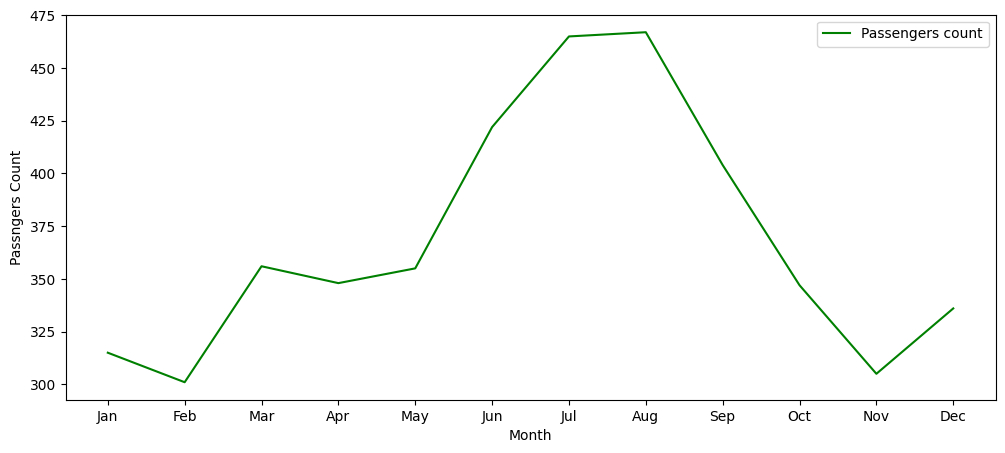

In [41]:
data = flights.query('year == 1957')
plt.figure(figsize=(12,5))
plt.plot(data.month, data.passengers, color='green', label='Passengers count')
plt.xlabel('Month')
plt.ylabel('Passngers Count')
plt.legend()
plt.show()

### 4. Візуалізація розподілів

**Завдання:**

* Побудуйте гістограму
* Побудуйте boxplot за кожним роком
* Зробіть висновки про форму розподілу та викиди

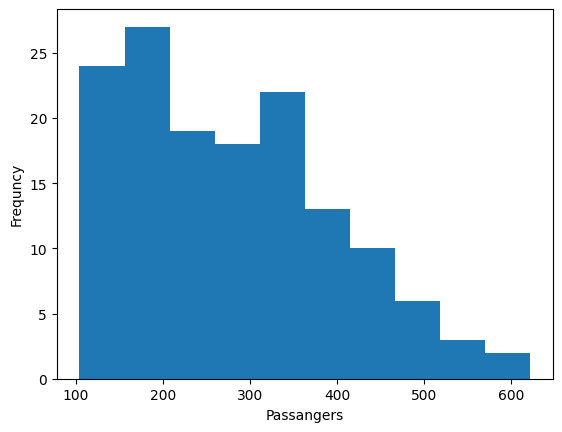

In [42]:
plt.hist(flights.passengers)
plt.xlabel('Passangers')
plt.ylabel('Frequncy')
plt.show()

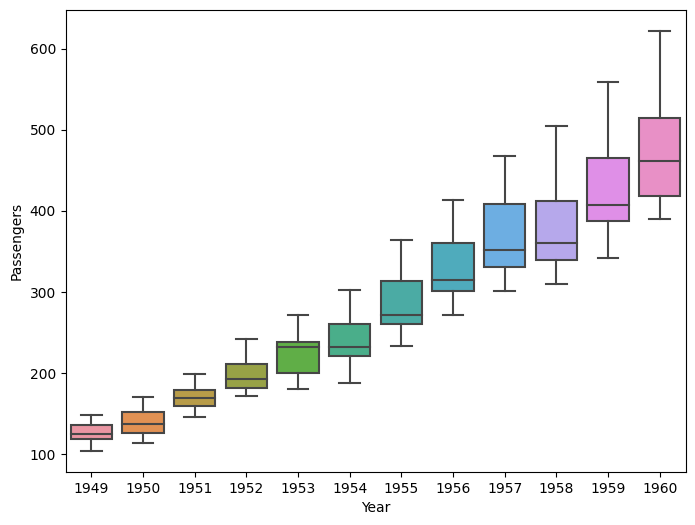

In [43]:
plt.figure(figsize=(8,6))
sns.boxplot(x='year', y='passengers', data=flights, orient='v')
plt.xlabel('Year')
plt.ylabel("Passengers")
plt.show()

### Висновки
З побудованих діаграм бачимо що розподіл даних право зміщений(right skewed), тобто було багато місяців в яких літало до 200 людей, також бачимо
викид між 300 та 350 пасажирів. З boxplot бачимо що є тренд на збільшення кількості людей які використовують перельоти.

### 5. Часовий аналіз і рухоме середнє

**Завдання:**

* Побудуйте графік пасажирів у часі
* Додайте рухоме середнє (вікно 12)

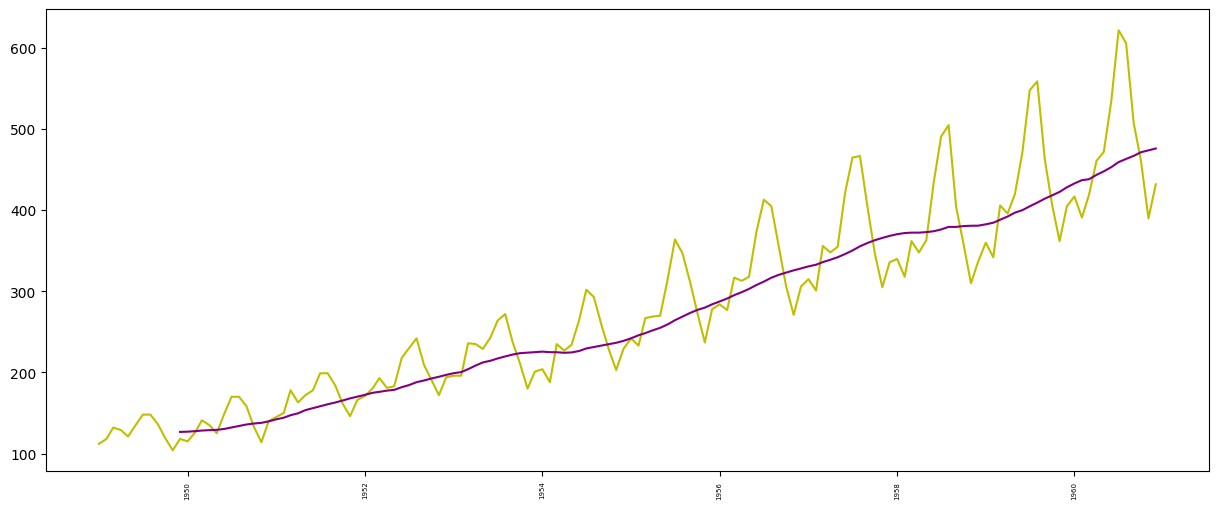

In [67]:
flights['date'] = flights.year.map(str).str.cat(flights.month, sep="-")
flights['date'] = pd.to_datetime(flights.year.map(str).str.cat(flights.month, sep="-"))
rolling_flight = flights['passengers'].rolling(12).mean()

plt.figure(figsize=(15,6))
plt.plot(flights.date, flights.passengers, color='y')
plt.plot(flights.date, rolling_flight.values, color='purple')
plt.xticks(fontsize=5, rotation=90)
plt.show()

### 6. Теплокарта

Завдання:
* Побудуйте теплокарту (рік × місяць) для пасажирів


In [45]:
# зтворимо pivot таблицю для візуалізації теплової карти
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
flights["month"] = pd.Categorical(flights["month"], categories=month_order, ordered=True)

flights_pivot = flights.pivot(index="month", columns="year", values="passengers")
flights_pivot.head()

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472


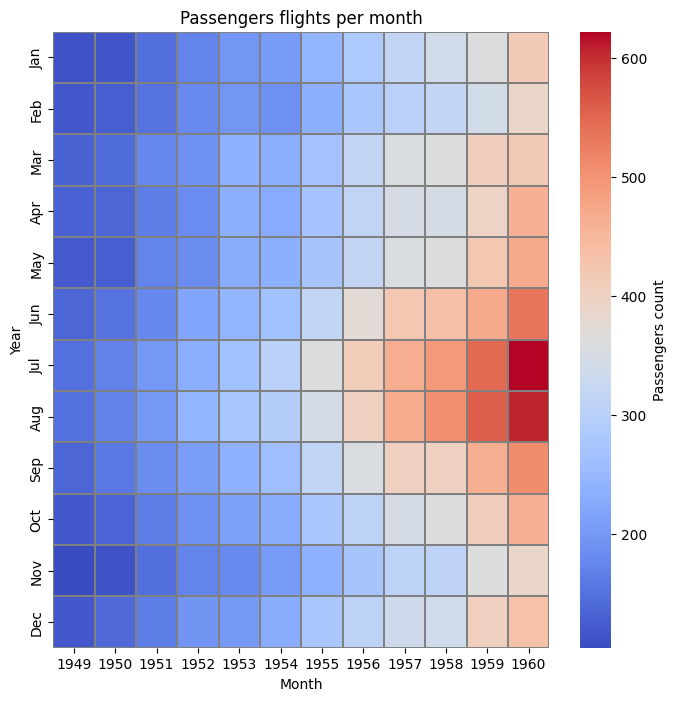

In [50]:
plt.figure(figsize=(8,8))
sns.heatmap(flights_pivot, cmap='coolwarm', linewidths=0.2, linecolor='grey', cbar_kws={'label':'Passengers count'})
plt.title('Passengers flights per month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()